### **Mount to the Drive**

In [1]:
base_dir = '/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd $base_dir

Mounted at /content/drive
/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2


In [3]:
!pip install torch
!pip install -U transformers timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 90.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [4]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small')
model = AutoModel.from_pretrained('facebook/dinov2-small', device_map="auto")
patch_size = model.config.patch_size

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [6]:
import cv2 as cv
import torch

left_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_2/000000.png'
right_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_3/000000.png'

left_img = cv.imread(left_img_path)
right_img = cv.imread(right_img_path)

new_w = (left_img.shape[1] // patch_size) * patch_size
new_h = (left_img.shape[0] // patch_size) * patch_size

left_img_resized = cv.resize(left_img, (new_w, new_h))
right_img_resized = cv.resize(right_img, (new_w, new_h))

left_resized_rgb = cv.cvtColor(left_img_resized, cv.COLOR_BGR2RGB)
right_resized_rgb = cv.cvtColor(right_img_resized, cv.COLOR_BGR2RGB)

inputs = processor(images=[left_resized_rgb, right_resized_rgb], do_resize=False, do_center_crop=False, return_tensors="pt").to(model.device)

batch_size, rgb, img_height, img_width = inputs.pixel_values.shape
num_patches_height, num_patches_width = img_height // patch_size, img_width // patch_size
num_patches_flat = num_patches_height * num_patches_width

with torch.no_grad():
  outputs = model(**inputs)

  cls_token = outputs.last_hidden_state[:, 0, :]
  patch_features = outputs.last_hidden_state[:, 1:, :].unflatten(1, (num_patches_height, num_patches_width))

  patch_features_vector=torch.flatten(patch_features, start_dim=1, end_dim=2)
  normalized_patch_features_vector = torch.nn.functional.normalize(patch_features_vector, p=2, dim=2)
  similarity_matrix = normalized_patch_features_vector[0] @ normalized_patch_features_vector[1].T

  left_most_similar = torch.argmax(similarity_matrix, dim=1)
  right_most_similar = torch.argmax(similarity_matrix, dim=0)
  indices = torch.arange(num_patches_flat)
  mutual_mask = (indices == right_most_similar[left_most_similar[indices]])

In [7]:
print(indices)
print(left_most_similar[indices])
print(right_most_similar[left_most_similar[indices]])
print(mutual_mask)
print(left_most_similar[indices[mutual_mask]])

tensor([   0,    1,    2,  ..., 2285, 2286, 2287])
tensor([  89,  264,    3,  ..., 2281, 2279, 2281])
tensor([   0,  264,    2,  ..., 2276, 2197, 2276])
tensor([ True, False,  True,  ..., False, False, False])
tensor([  89,    3,    1,  ..., 2274, 2275, 2276])


In [8]:
import numpy as np

num_mutual_pts = len(indices[mutual_mask])
left_pts = np.zeros((num_mutual_pts, 2), dtype = np.int32)
right_pts = np.zeros((num_mutual_pts, 2), dtype = np.int32)

for i, idx in enumerate(indices[mutual_mask]):
  left_idx = int(idx)
  lx = int(((left_idx % num_patches_width) + 0.5) * patch_size)
  ly = int(((left_idx // num_patches_width) + 0.5) * patch_size)

  right_idx = left_most_similar[left_idx]
  rx = int(((right_idx % num_patches_width) + 0.5) * patch_size)
  ry = int(((right_idx // num_patches_width) + 0.5) * patch_size)

  left_pts[i] = [lx, ly]
  right_pts[i] = [rx, ry]

F, mask = cv.findFundamentalMat(left_pts, right_pts, cv.FM_RANSAC)

In [9]:
mask = mask.flatten().astype(bool)
left_pts_masked = left_pts[mask]
right_pts_masked = right_pts[mask]

print("=Mask=")
print(mask[0])
print(mask[1])
print("---------------------")
print("=Left Matched Points=")
print(left_pts[0])
print(left_pts[1])
print("----------------------------")
print("=Left Matched Masked Points=")
print(left_pts_masked[0])
print(left_pts_masked[1])

=Mask=
False
True
---------------------
=Left Matched Points=
[7 7]
[35  7]
----------------------------
=Left Matched Masked Points=
[35  7]
[63  7]


# **Computing Epipolar Lines**

In [10]:
lines1 = cv.computeCorrespondEpilines(right_pts_masked, 2, F)
lines2 = cv.computeCorrespondEpilines(left_pts_masked, 1, F)

print(lines1)

[[[-6.6458976e-15 -1.0000000e+00  7.0000000e+00]]

 [[-6.6461195e-15 -1.0000000e+00  7.0000000e+00]]

 [[-6.6455639e-15 -1.0000000e+00  7.0000000e+00]]

 ...

 [[-1.5173855e-14 -1.0000000e+00  3.5700000e+02]]

 [[-1.5173743e-14 -1.0000000e+00  3.5700000e+02]]

 [[-1.5173631e-14 -1.0000000e+00  3.5700000e+02]]]


In [11]:
import matplotlib.pyplot as plt

In [12]:
# Input type: BGR
def stereo_img_viewer(left_img, right_img):
  left_img_rgb = cv.cvtColor(left_img, cv.COLOR_BGR2RGB)
  right_img_rgb = cv.cvtColor(right_img, cv.COLOR_BGR2RGB)

  fig, axs = plt.subplots(1, 2, figsize=(12, 3))
  fig.suptitle('Sequence 00 | First Images')

  axs[0].imshow(left_img_rgb)
  axs[0].set_title('image_2')
  axs[1].imshow(right_img_rgb)
  axs[1].set_title('image_3')

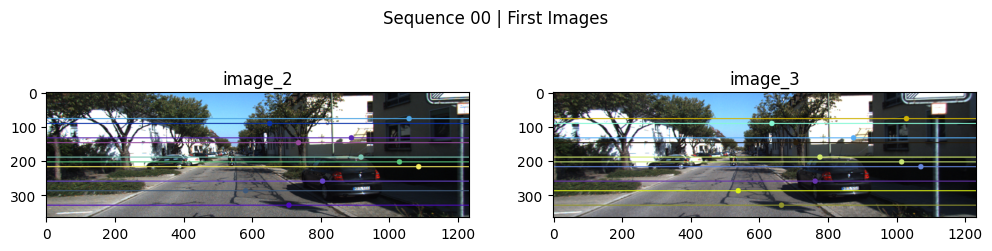

In [21]:
import random

def draw_epilines(img, lines, pts):
  h, w, _ = img.shape
  pts = pts.astype(np.int_)
  for line, pt in zip(lines, pts):
    a, b, c = line[0]
    x1 = 0
    y1 = int(-c/b)
    x2 = w-1
    y2 = int(((-a*x2) - c) / b)
    color = tuple(np.random.randint(0,255,3).tolist())
    cv.line(img, (x1, y1), (x2, y2), color, 2)
    cv.circle(img, pt, 8, color, -1)

  return img

num_inliers = len(left_pts_masked)
random_indices = random.sample(range(num_inliers), 10)

sample_left_pts = left_pts_masked[random_indices]
sample_right_pts = right_pts_masked[random_indices]

sample_lines1 = cv.computeCorrespondEpilines(sample_right_pts, 2, F)
sample_lines2 = cv.computeCorrespondEpilines(sample_left_pts, 1, F)

left_img_with_lines = draw_epilines(left_img_resized.copy(), sample_lines1, sample_left_pts)
right_img_with_lines = draw_epilines(right_img_resized.copy(), sample_lines2, sample_right_pts)

stereo_img_viewer(left_img_with_lines, right_img_with_lines)